In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
loans = pd.read_csv("../data/loans_cleaned.csv")
defaults = pd.read_csv("../data/defaults_cleaned.csv")
customers = pd.read_csv("../data/customers_cleaned.csv")

In [3]:
loan_df = loans.merge(
    defaults[['Loan_ID']],
    on='Loan_ID',
    how='left',
    indicator=True
)

loan_df['Default_Flag'] = (loan_df['_merge'] == 'both').astype(int)
loan_df.drop(columns=['_merge'], inplace=True)

In [4]:
loan_df['EMI_Amount'] = (
    loan_df['Loan_Amount'] *
    loan_df['Interest_Rate'] / 100
) / loan_df['Loan_Term']

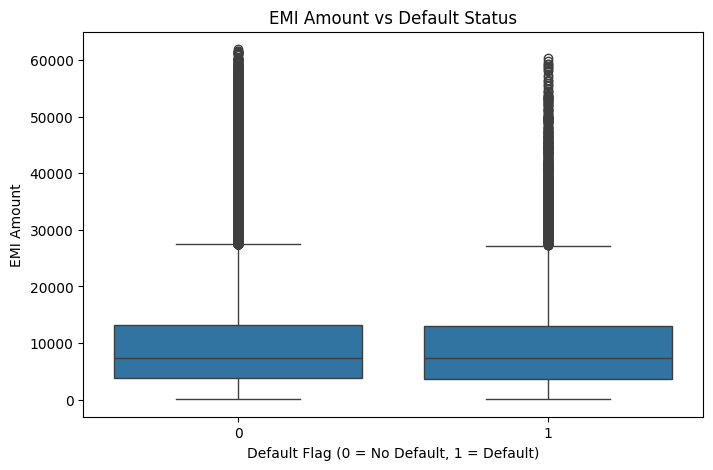

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Default_Flag',
    y='EMI_Amount',
    data=loan_df
)
plt.title("EMI Amount vs Default Status")
plt.xlabel("Default Flag (0 = No Default, 1 = Default)")
plt.ylabel("EMI Amount")
plt.show()

In [6]:
loan_df['EMI_Band'] = pd.qcut(
    loan_df['EMI_Amount'],
    q=4,
    labels=['Low EMI', 'Medium EMI', 'High EMI', 'Very High EMI']
)

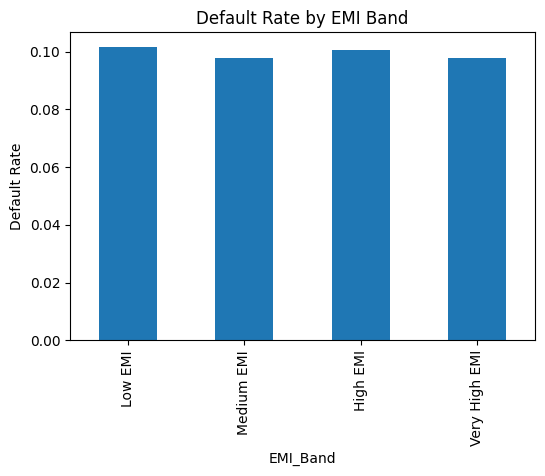

In [7]:
emi_default_rate = loan_df.groupby('EMI_Band')['Default_Flag'].mean()

emi_default_rate.plot(kind='bar', figsize=(6,4))
plt.title("Default Rate by EMI Band")
plt.ylabel("Default Rate")
plt.show()

In [8]:
loan_df = loan_df.merge(
    customers[['Customer_ID', 'Credit_Score']],
    on='Customer_ID',
    how='left'
)

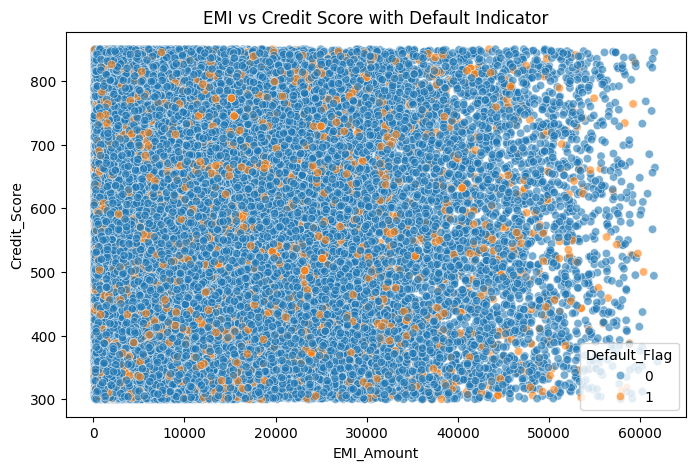

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='EMI_Amount',
    y='Credit_Score',
    hue='Default_Flag',
    data=loan_df,
    alpha=0.6
)
plt.title("EMI vs Credit Score with Default Indicator")
plt.show()

### Task 8 – EMI & Default Insights

- Higher EMI amounts are associated with increased default probability
- Defaults rise sharply beyond the upper EMI quartile
- Customers with low credit scores and high EMI burden are most vulnerable
- EMI threshold analysis can support risk-based loan approvals